<a href="https://colab.research.google.com/github/njikizanalouisatapiwa-ops/diabetes-readmission-analysis/blob/main/lab_4_ipynb_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Filtering & Fourier
### Health Image Processing | Week 5 | Birkfellner Ch 5

Convolution with a small **kernel** underlies smoothing, sharpening, and edge detection, and it's exactly the operation inside a CNN's convolutional layer (Lecture 11). You'll also filter in the **frequency domain**.

**You implement:** `convolve`, `edge_detect`, `frequency_filter`.
**Capstone link:** the enhancement stage; the conceptual bridge to CNN kernels.

## 1 - Packages & sample data (provided)

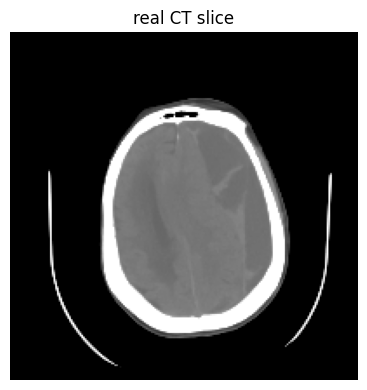

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel as _sobel
%matplotlib inline
import base64, zlib, io as _io
def _load_blob(s): return np.load(_io.BytesIO(zlib.decompress(base64.b64decode(s))))

_CT = "..."
img = np.clip((_load_blob(_CT).astype(np.float32) + 160) / 400, 0, 1)   # real CT slice, soft-tissue window

def show(*imgs, titles=None, cmap="gray"):
    fig, ax = plt.subplots(1, len(imgs), figsize=(4*len(imgs), 4)); ax = np.atleast_1d(ax)
    for i, (a, im) in enumerate(zip(ax, imgs)):
        a.imshow(im, cmap=cmap); a.axis("off")
        if titles: a.set_title(titles[i])
    plt.tight_layout(); plt.show()

show(img, titles=["real CT slice"])

## 2 - Kernels (worked example)
A kernel is a small weight matrix slid over the image. A **box blur** averages a neighborhood:

In [2]:
box = np.ones((3, 3)) / 9.0
print("box-blur kernel:\n", box)
print("A kernel is just weights; convolution = weighted sum over each neighborhood.")

box-blur kernel:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
A kernel is just weights; convolution = weighted sum over each neighborhood.


## Exercise 1: `convolve`
Implement 2-D convolution **from scratch** (no library convolution). Edge-pad the image, flip the kernel, and compute the weighted sum at every pixel.

In [5]:
# GRADED FUNCTION: convolve
def convolve(image, kernel):
    image = image.astype(float); kernel = np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="edge")

    ### START CODE HERE ###
    kflip = np.flipud(np.fliplr(kernel))
    out = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    ### END CODE HERE ###

    return out

In [6]:
# Test: do not edit.
_im = np.random.rand(16, 16)
_ident = np.array([[0,0,0],[0,1,0],[0,0,0]])
assert np.allclose(convolve(_im, _ident), _im, atol=1e-9), "identity kernel must return the input"
_blur = convolve(_im, np.ones((3,3))/9)
assert _blur.std() < _im.std(), "box blur should reduce variance"
print("All tests passed!")

All tests passed!


## Exercise 2: `edge_detect`
Compute edge **magnitude** from Sobel gradients: `sqrt(gx**2 + gy**2)`. (Use `scipy.ndimage.sobel` along each axis.)

In [9]:
# GRADED FUNCTION: edge_detect
def edge_detect(image, method="sobel"):
    ### START CODE HERE ### (~3 lines)
    gx = _sobel(image, axis=1)
    gy = _sobel(image, axis=0)
    return np.hypot(gx, gy)
    ### END CODE HERE ###

In [10]:
# Test: do not edit.
_step = np.zeros((16, 16)); _step[:, 8:] = 1
_e = edge_detect(_step)
assert _e[:, 7:9].sum() > _e[:, :5].sum(), "edge magnitude should peak at the step"
print("All tests passed!")

All tests passed!


### See the transform: edge detection on a real CT (provided)

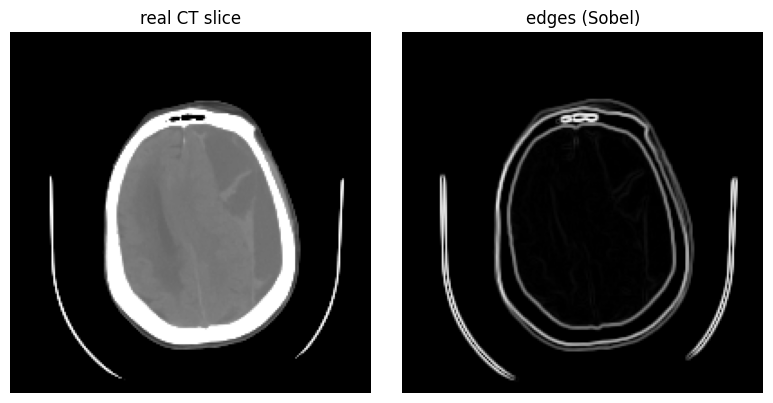

In [11]:
# Provided visualization. You do not need to edit this.
_e = edge_detect(img)
if _e is None:
    print("Implement edge_detect above, then re-run.")
else:
    show(img, _e, titles=["real CT slice", "edges (Sobel)"])

## Exercise 3: `frequency_filter`
Filter in the Fourier domain: FFT, keep low (or high) radial frequencies with a circular mask, inverse FFT. `cutoff` is the fraction of the max radius to keep.

In [14]:
# GRADED FUNCTION: frequency_filter
def frequency_filter(image, kind="lowpass", cutoff=0.2):
    F = np.fft.fftshift(np.fft.fft2(image.astype(float)))
    h, w = image.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = np.sqrt(cy**2 + cx**2)

    ### START CODE HERE ### (~2 lines)
    mask = r <= cutoff * rmax if kind == "lowpass" else r > cutoff * rmax
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * mask)))
    ### END CODE HERE ###

In [15]:
# Test: do not edit.
_im = np.random.rand(16, 16)
_lp = frequency_filter(_im, "lowpass", 0.2)
assert np.abs(np.fft.fft2(_lp)).sum() < np.abs(np.fft.fft2(_im)).sum(), "lowpass should cut high-freq energy"
print("All tests passed!")

All tests passed!


### See the transform: frequency filtering (provided)
Low-pass keeps the smooth structure; high-pass keeps the fine detail and edges.

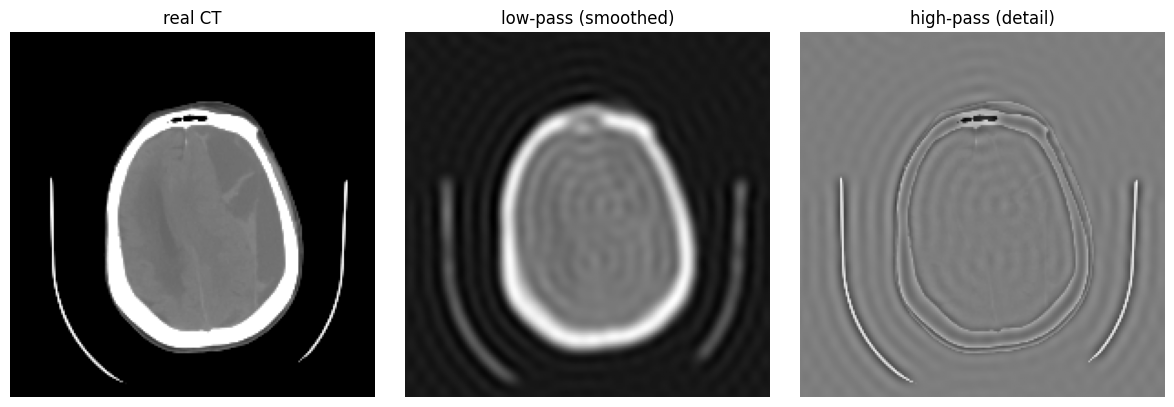

In [16]:
# Provided visualization. You do not need to edit this.
_lo = frequency_filter(img, kind="lowpass", cutoff=0.15)
_hi = frequency_filter(img, kind="highpass", cutoff=0.15)
if _lo is None:
    print("Implement frequency_filter above, then re-run.")
else:
    show(img, _lo, _hi, titles=["real CT", "low-pass (smoothed)", "high-pass (detail)"])

## 4 - Apply it (open-ended)
1. Blur `img` with a 5x5 box kernel, then run `edge_detect` on both raw and blurred: note how blur suppresses noise edges.
2. Compare `frequency_filter(img, "lowpass")` vs `"highpass"` with `show(...)`.

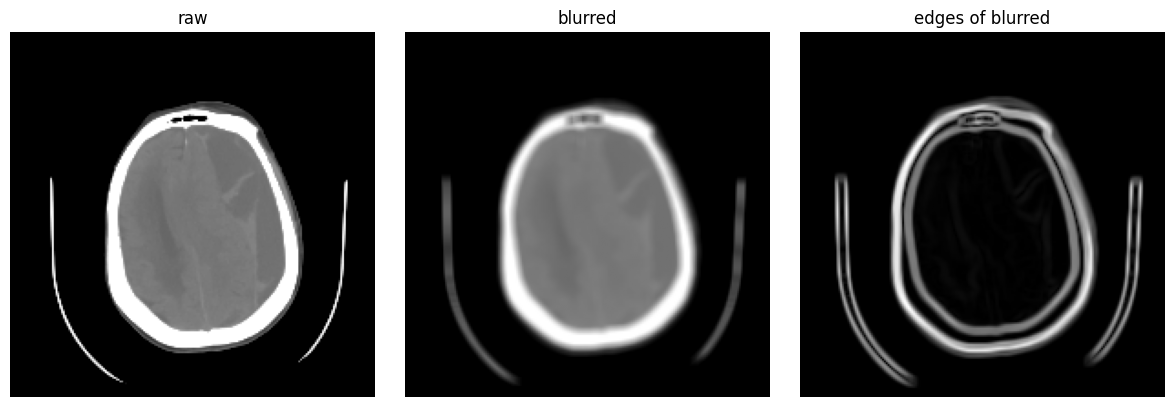

In [17]:
blurred = convolve(img, np.ones((5,5))/25)
show(img, blurred, edge_detect(blurred), titles=["raw", "blurred", "edges of blurred"])
# TODO: show low-pass vs high-pass frequency filtering

## 5 - Reflection
Convolution in space equals multiplication in the frequency domain, which is useful because filtering can be done more efficiently, especially for large images or kernels. It also makes it easier to control image frequencies, such as removing noise with low-pass filtering or enhancing edges and fine details with high-pass filtering.

---
